In [1]:
# conda create --name bcitoolbox python=3.10

from bcitoolbox_local import simulateVV, fit
import pandas as pd
import numpy as np
# import cupy as cp
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.stats import wilcoxon
import statsmodels.api as sm
from collections import defaultdict

In [2]:
strategy_map = {
    'Averaging': 'ave',
    'Selection': 'sel',
    'Matching': 'mat',
}

model_map = {
    'bci': 'Bayesian Causal Inference',
    'ff':  'Forced Fusion',
    'mle': 'Maximum Likelihood estimation',
    'fs': 'Full Segregation'
}


location_map = {
    'all': 'All',
    'blindspot': 'Blind Spot',
    'control': 'Control',
}

param_groups = {
    'Prior': ['pcommon', 'sigma_p', 'mu_p'],
    'Visual': ['sigma_v'],
    'Auditory': ['sigma_a'],
    'Model': ['r2', 'bic']
}

def simulate_data(parameters, strategy_name, fitType, file_name,
                  modeling_data_path='csv/modeling/',
                  n_simulation=1000, biOnly=0):
    
    data_file_path = modeling_data_path + file_name
    behavior_data = np.loadtxt(data_file_path, delimiter=',')
    strategy = strategy_map.get(strategy_name[0])

    error, modelprop, dataprop, responsesSim, r2 = simulateVV(parameters, n_simulation, behavior_data, biOnly, strategy, fitType)

    return error, modelprop, dataprop, responsesSim, r2

def get_subject_ids():
    # Get unique subject IDs
    subject_ids = set()
    for filename in os.listdir('csv/modeling/'):
        if 'df_all' and 'SV0' in filename:
            parts = filename.split('_')
            subject = parts[-1].replace('.csv', '')    
            subject_ids.add(subject)
            
    return sorted(list(subject_ids))


def get_best_models(model, remove_all_loc=True):
    
    df = pd.read_csv(f'csv/modeling/{model}_best_models.csv')
    if remove_all_loc:
        df = df[df['location'] != 'all']
        
    return df

def get_all_models(model, strategy=None, remove_all_loc=True):
    
    df = pd.read_csv(f'csv/modeling/{model}_fitting_results.csv')
    if strategy is not None:
        df = df[df['strategy']==strategy]
    if remove_all_loc:
        df = df[df['location'] != 'all']
        
    return df

def compare_bic_scores():
    bci_models = get_best_models('bci')
    print('\n======== Bayesian Causal Inference =============')
    bci_means = bci_models.groupby(['location'])['bic'].agg(['sum', 'mean', 'sem']).round(2)
    print(bci_means)

    ff_models = get_best_models('ff')
    print('\n======== Forced Fusion (p-common = 1) =============')
    ff_means = ff_models.groupby(['location'])['bic'].agg(['sum', 'mean', 'sem']).round(2)
    print(ff_means)

    fs_models = get_best_models('fs')
    print('\n======== Full Segregation (p-common = 0) =============')
    fs_means = fs_models.groupby(['location'])['bic'].agg(['sum', 'mean', 'sem']).round(2)
    print(fs_means)
    
    mle_models = get_best_models('mle')
    print('\n======== Maximum Likelihood Estimation (no prior) =============')
    mle_means = mle_models.groupby(['location'])['bic'].agg(['sum', 'mean', 'sem']).round(2)
    print(mle_means)


    results = {
        'blindspot': {
            'bci': bci_means.loc['blindspot']['mean'],
            'ff': ff_means.loc['blindspot']['mean'],
            'mle': mle_means.loc['blindspot']['mean'],
            'fs': fs_means.loc['blindspot']['mean'],
        },
        'control': {
            'bci': bci_means.loc['control']['mean'],
            'ff': ff_means.loc['control']['mean'],
            'mle': mle_means.loc['control']['mean'],
            'fs': fs_means.loc['control']['mean'],
        }
    }

    print('\n======== Best Model by Location (Lowest BIC) =============')

    best_model_bs = min(results['blindspot'], key=results['blindspot'].get)
    min_bic_bs = results['blindspot'][best_model_bs]
    print(f"For 'blindspot', the best model is '{best_model_bs.upper()}' with a mean BIC of {min_bic_bs:.2f}.")
    print(f"Average r-squared = {get_best_models(best_model_bs)['r2'].mean():.2f}\n")

    best_model_ctrl = min(results['control'], key=results['control'].get)
    min_bic_ctrl = results['control'][best_model_ctrl]
    print(f"For 'control',   the best model is '{best_model_ctrl.upper()}' with a mean BIC of {min_bic_ctrl:.2f}.")
    print(f"Average r-squared = {get_best_models(best_model_ctrl)['r2'].mean():.2f}\n")

    return best_model_bs, best_model_ctrl

def print_parameters(model, show_strategy=False):

    df = get_best_models(model)

    all_parameters = [p for sublist in param_groups.values() for p in sublist]

    tidy_df = df.melt(
        id_vars=['subject_id', 'location', 'strategy'],
        value_vars=all_parameters,
        var_name='parameter',
        value_name='value'
    )

    param_to_type_map = {
        param: group_name 
        for group_name, param_list in param_groups.items() 
        for param in param_list
    }
    tidy_df['parameter_type'] = tidy_df['parameter'].map(param_to_type_map)
    
    if show_strategy:
        print(tidy_df.groupby(['parameter_type', 'parameter', 'strategy', 'location'])['value'].agg(['mean', 'sem']).round(2))
    else:
        print(tidy_df.groupby(['parameter_type', 'parameter', 'location'])['value'].agg(['mean', 'sem']).round(2))

def print_strategy(model):
    df = get_best_models(model)

    counts = (
        df.groupby('location')['strategy']
          .value_counts(normalize=True)
          .rename('% win')
          .mul(100)
          .reset_index()
    )

    print(counts)


In [3]:
# Find best model and print goodness-of-fit (r-squared)
best_model_bs, best_model_ctrl = compare_bic_scores()


======== Bayesian Causal Inference =============
               sum    mean   sem
location                        
blindspot  3205.70  160.28  12.4
control    2629.39  131.47  10.9

======== Forced Fusion (p-common = 1) =============
               sum    mean    sem
location                         
blindspot  4211.26  210.56  20.49
control    3193.41  159.67  15.37

======== Full Segregation (p-common = 0) =============
               sum    mean    sem
location                         
blindspot  4517.06  225.85  21.55
control    3827.41  191.37  13.70

======== Maximum Likelihood Estimation (no prior) =============
               sum    mean    sem
location                         
blindspot  4906.51  245.33  23.71
control    3660.40  183.02  19.02

======== Best Model by Location (Lowest BIC) =============
For 'blindspot', the best model is 'BCI' with a mean BIC of 160.28.
Average r-squared = 0.99

For 'control',   the best model is 'BCI' with a mean BIC of 131.47.
Average r-squa

C:\Users\Ailene\AppData\Local\Temp\ipykernel_39832\85189627.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)


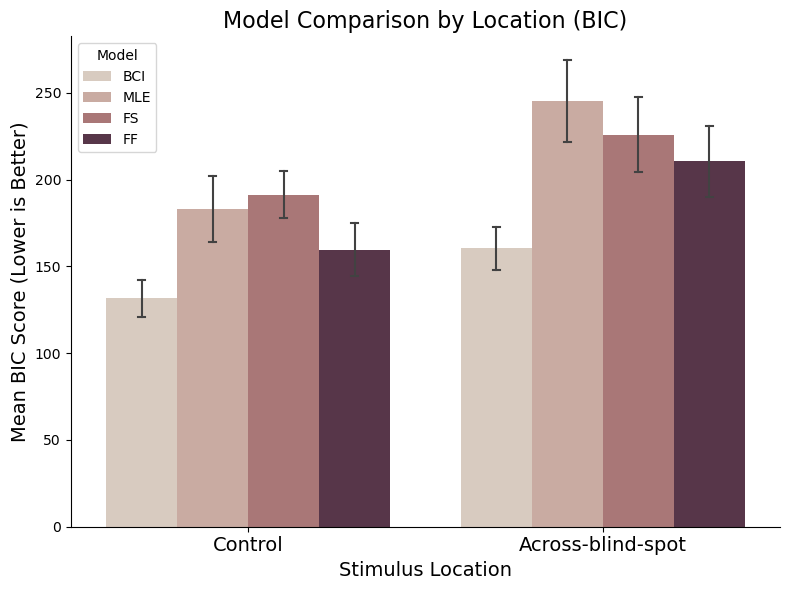

In [14]:
model_order = ['bci', 'mle', 'fs', 'ff']
location_order = ['control', 'blindspot']
location_display = {
    'control': 'Control',
    'blindspot': 'Across-blind-spot',
}
custom_palette = {
    'BCI': '#dccabc',
    'MLE': '#cfa79c',
    'FS': '#b16f6f',
    'FF': '#5c314a',
}

bic_plot_df = pd.concat(
    [
        get_best_models(model)
        .assign(model=model.upper())
        [['subject_id', 'location', 'bic', 'model']]
        for model in model_order
    ],
    ignore_index=True,
)

bic_plot_df['location_label'] = pd.Categorical(
    bic_plot_df['location'].map(location_display),
    categories=[location_display[loc] for loc in location_order],
    ordered=True,
)
bic_plot_df['model'] = pd.Categorical(
    bic_plot_df['model'],
    categories=[model.upper() for model in model_order],
    ordered=True,
)

fig, ax = plt.subplots(figsize=(8, 6))

sns.barplot(
    data=bic_plot_df,
    x='location_label',
    y='bic',
    hue='model',
    order=[location_display[loc] for loc in location_order],
    hue_order=[model.upper() for model in model_order],
    palette=custom_palette,
    errorbar='se',
    capsize=0.08,
    err_kws={'linewidth': 1.5},
    ax=ax,
)

ax.set_title('Model Comparison by Location (BIC)', fontsize=16)
ax.set_xlabel('Stimulus Location', fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)
ax.set_ylabel('Mean BIC Score (Lower is Better)', fontsize=14)
ax.legend(title='Model', frameon=True)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


In [5]:
# Print parameters of best model, do wilcoxon
model = 'bci'
print('\n======== Bayesian Causal Inference Fitted Parameters =============')
print_parameters(model)
print('\n--- Best Strategies for Each Participant and Location ---')
print_strategy(model)


======== Bayesian Causal Inference Fitted Parameters =============
                                      mean    sem
parameter_type parameter location                
Auditory       sigma_a   blindspot    0.21   0.02
                         control      0.19   0.01
Model          bic       blindspot  160.28  12.40
                         control    131.47  10.90
               r2        blindspot    0.99   0.00
                         control      0.99   0.00
Prior          mu_p      blindspot    1.90   0.14
                         control      2.33   0.16
               pcommon   blindspot    0.50   0.06
                         control      0.58   0.08
               sigma_p   blindspot    1.19   0.14
                         control      0.84   0.07
Visual         sigma_v   blindspot    2.32   0.12
                         control      1.32   0.16

--- Best Strategies for Each Participant and Location ---
    location   strategy  % win
0  blindspot  Averaging   45.0
1  blindspo

Data Analysis

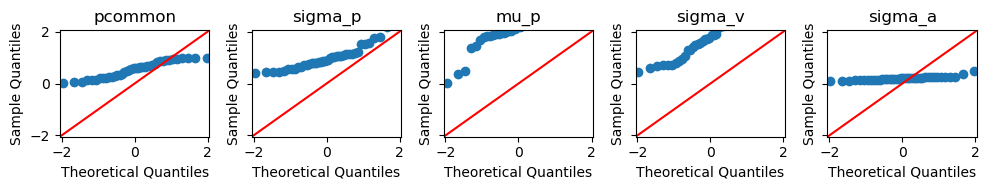

======= Wilcoxon Signed-Rank Test ===========
Comparing 5 parameters between 'BlindSpot' and 'Control' locations.


,parameters,W,p,p_bonf,sig
0,pcommon,49.0,0.036234,0.181170,False
1,sigma_p,16.0,0.000322,0.001612,True
2,mu_p,18.0,0.000483,0.002413,True
3,sigma_v,9.0,0.000063,0.000315,True
4,sigma_a,81.0,0.388376,1.000000,False


In [6]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

best_model = get_best_models(model)

parameters = ['pcommon', 'sigma_p', 'mu_p', 'sigma_v', 'sigma_a']

fig, axes = plt.subplots(ncols=5, nrows=1, figsize=(10, 2), sharey=True)
for i, param in enumerate(parameters):
    sm.qqplot(best_model[param], line='45', ax=axes[i])
    axes[i].set_title(param)
plt.tight_layout()
plt.show()

# Since data is not normal, use Wilcoxon sign-rank test (repeated test) to compare parameters across locations
print("======= Wilcoxon Signed-Rank Test ===========")
print(f"Comparing {len(parameters)} parameters between 'BlindSpot' and 'Control' locations.")

results = []
for param in parameters:
    wide = (best_model
            .pivot(index='subject_id', columns='location', values=param)
            .dropna(axis=0, how='any'))

    if {'blindspot', 'control'}.issubset(wide.columns):
        x = wide['blindspot']
        y = wide['control']
    elif len(wide.columns) == 2:
        cols = list(wide.columns)
        x = wide[cols[0]]
        y = wide[cols[1]]
    else:
        # Not enough data to compare
        continue

    common = x.index.intersection(y.index)
    if len(common) == 0:
        continue
    x = x.loc[common]
    y = y.loc[common]

    diffs = x - y
    if np.all(diffs == 0):
        continue

    W, p = wilcoxon(x, y, alternative='two-sided', zero_method='wilcox')

    results.append({
        'parameters': param,
        'W': float(W),
        'p': float(p)
    })

within_df = pd.DataFrame(results)

reject, p_bonf, _, _ = multipletests(within_df['p'].values, method='bonferroni')
within_df['p_bonf'] = p_bonf
within_df['sig'] = reject
display(within_df)


Simulated vs Actual data

In [7]:
# Plot actual data vs simulated data for best models only
condition_map = None
best_models_df = get_best_models('bci')
all_props = defaultdict(dict)

for location in ['blindspot', 'control']:
    location_df = best_models_df[best_models_df['location'] == location]

    for index, row in location_df.iterrows():
        subject = row['subject_id']
        file_name = f"df_{location}_{subject}.csv"
        Strategies = [row['strategy']]
        FitType = row['fit_type']

        if condition_map is None:
            behavior_data = np.loadtxt(f'csv/modeling/{file_name}', delimiter=',')
            stimuli = behavior_data[:, [0, 1]]
            condition_map = np.unique(stimuli, axis=0)

        print("\n=======================================")
        print(f"Simulating data for {subject} at {location}")
        print("=======================================\n")

        parameters = [
            row['pcommon'],
            row['sigma_v'],
            row['sigma_a'],
            row['sigma_p'],
            row['mu_p'],
        ]
        error, modelprop, dataprop, responsesSim, r2 = simulate_data(parameters, Strategies, FitType, file_name)

        # store simulated data
        all_props[subject][location] = {
            'modelprop': modelprop,
            'dataprop': dataprop,
            'r2': r2,
            'pcommon':  row['pcommon'],
            'sigma_v': row['sigma_v'],
            'sigma_a': row['sigma_a'],
            'sigma_p': row['sigma_p'],
            'mu_p': row['mu_p']
        }

        # Split modelprop and dataprop according to conditions
        for i, condition in enumerate(condition_map):
            all_props[subject][location][f'F{int(condition[0])}B{int(condition[1])}'] = {
                'Visual model': modelprop[0, i, :],
                'Visual response': dataprop[0, i, :],
                'Auditory model': modelprop[1, i, :],
                'Auditory response': dataprop[1, i, :],
            }


Simulating data for SV009 at blindspot

fit type = mll
===== DEBUG: fixed values = [0.5, 0.4, 0.8, 4000, 2, 0, 0] =====
===== DEBUG: pcommon = 0.3466990018256258 =====
===== DEBUG: sigma_v = 1.9242029083175345 =====
===== DEBUG: sigma_a = 0.2538983132368169 =====
===== DEBUG: sigma_p = 2.1641306692293685 =====
===== DEBUG: mu_p = 0.3711814679266927 =====
Explainable variance, r2:
0.9711877237850183

Simulating data for SV012 at blindspot

fit type = mll
===== DEBUG: fixed values = [0.5, 0.4, 0.8, 4000, 2, 0, 0] =====
===== DEBUG: pcommon = 0.588934592724969 =====
===== DEBUG: sigma_v = 2.957184620507101 =====
===== DEBUG: sigma_a = 0.2420158910369532 =====
===== DEBUG: sigma_p = 2.993957520443737 =====
===== DEBUG: mu_p = 2.459226505459625 =====
Explainable variance, r2:
0.9626628654970713

Simulating data for SV013 at blindspot

fit type = mll
===== DEBUG: fixed values = [0.5, 0.4, 0.8, 4000, 2, 0, 0] =====
===== DEBUG: pcommon = 0.6918770913745358 =====
===== DEBUG: sigma_v = 2.5944

<Figure size 640x480 with 0 Axes>

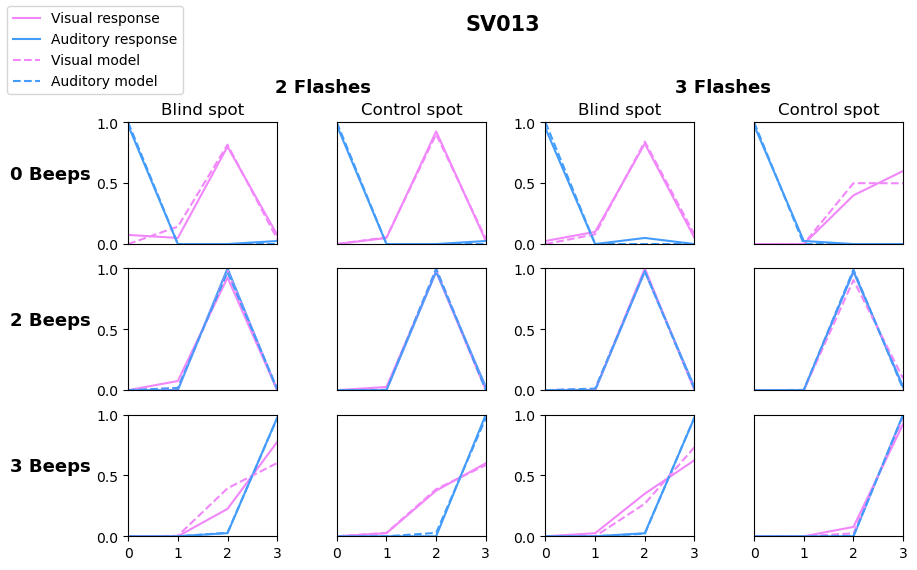

In [8]:
location_map = {
     'blindspot': 'Blind spot',
     'control': 'Control spot',
}

beep_map = {
        'B0': '0 Beeps',
        'B2': '2 Beeps',
        'B3': '3 Beeps',
}

vis_col = '#f187fb'
aud_col = '#439cfb'

subject_ids = get_subject_ids()
subject_ids = ['SV013']
for subject_id in subject_ids:
        
        # start plotting
        fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(10, 6))
        plt.suptitle(subject_id, fontsize='15', fontweight='bold')
        flattened_axes = axes.flatten()
        ax=0

        for condition in ['F2B0', 'F3B0', 'F2B2', 'F3B2', 'F2B3', 'F3B3']:
             for location in ['blindspot', 'control']:
                
                # Behavioral Data
                flattened_axes[ax].plot(all_props[subject_id][location][condition]['Visual response'], vis_col, label='Visual response')
                flattened_axes[ax].plot(all_props[subject_id][location][condition]['Auditory response'], aud_col, label='Auditory response')
                
                # Simulated Data
                flattened_axes[ax].plot(all_props[subject_id][location][condition]['Visual model'], vis_col, linestyle='--', label='Visual model')
                flattened_axes[ax].plot(all_props[subject_id][location][condition]['Auditory model'], aud_col, linestyle='--', label='Auditory model')
                            
                flattened_axes[ax].axis([0, 3, 0, 1])

                # aesthetics

                # only show y ticks on blind spot columns
                flattened_axes[ax].set_yticks([0, 0.5, 1]) if location=='blindspot' else flattened_axes[ax].set_yticks([])

                # only show x ticks on 3 beeps rows
                flattened_axes[ax].set_xticks([0, 1, 2, 3]) if 'B3' in condition else flattened_axes[ax].set_xticks([])

                # show location at top row (0 beeps)
                flattened_axes[ax].set_title(location_map[location]) if 'B0' in condition else None

                # show beep conditions on blind spot columns
                if location=='blindspot' and 'F2' in condition:
                    for key, label in beep_map.items():
                        if key in condition:
                            flattened_axes[ax].set_ylabel(label, rotation=0, ha='right', fontsize=13, fontweight='bold')
                            break
                # move on to next subplot
                ax+=1


        fig.subplots_adjust(top=0.80, wspace=0.4)
        fig.text(x=0.32, y=0.85, s='2 Flashes', ha='center', fontsize=13, fontweight='bold')
        fig.text(x=0.72, y=0.85, s='3 Flashes', ha='center', fontsize=13, fontweight='bold')

        # legend
        handles, labels = flattened_axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper left', fontsize=10)

        plt.show()


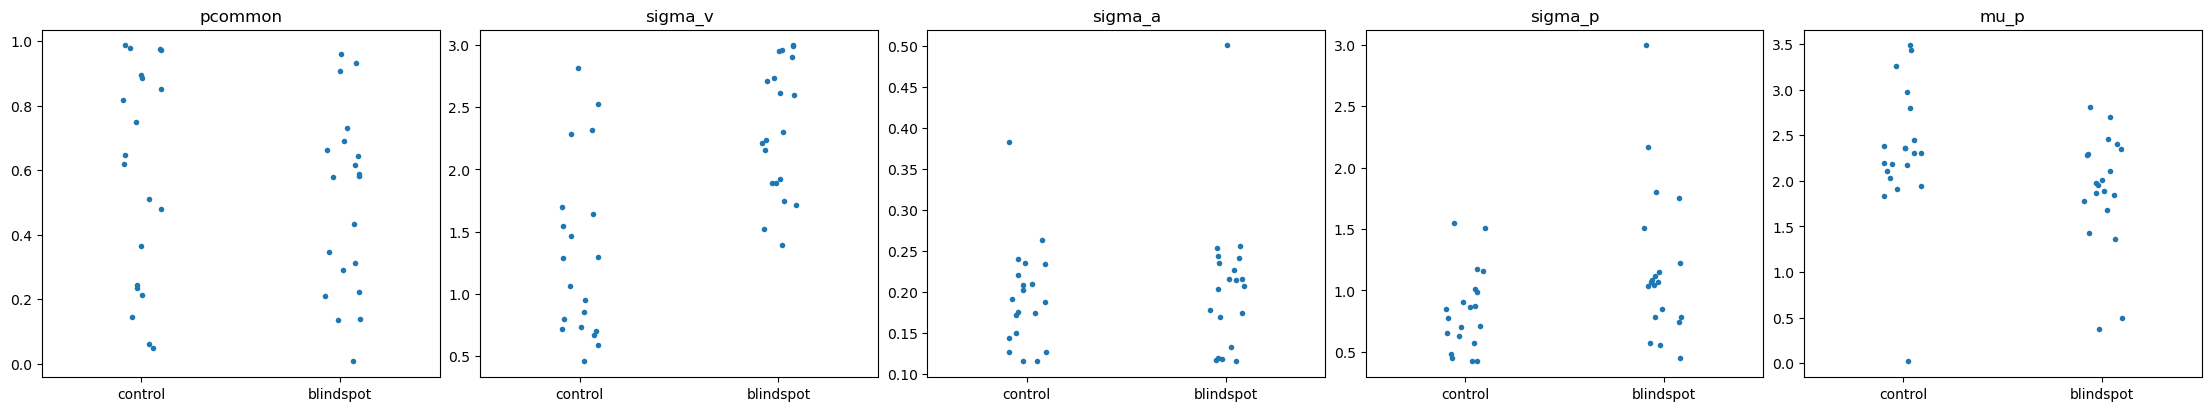

In [9]:
df = get_best_models('bci')

all_parameters = [p for sublist in param_groups.values() for p in sublist]

tidy_df = df.melt(
    id_vars=['subject_id', 'location', 'strategy'],
    value_vars=all_parameters,
    var_name='parameter',
    value_name='value'
)

# five parameters only
PARAMS5 = ["pcommon", "sigma_v", "sigma_a", "sigma_p", "mu_p"]

d5 = tidy_df[tidy_df["parameter"].isin(PARAMS5)].copy()

# optional: ensure consistent order
loc_order = ["control", "blindspot"]

fig, axes = plt.subplots(1, 5, figsize=(22, 4), constrained_layout=True)

for ax, p in zip(axes, PARAMS5):
    dp = d5[d5["parameter"] == p]

    sns.stripplot(
        data=dp,
        x="location",
        y="value",
        order=loc_order,
        ax=ax,
        size=4
    )

    ax.set_title(p)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.show()

